# 03 - RL Trading Agents

Goal: compare Q-learning, PPO, random policy, and buy-and-hold.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nvda_rl.agents import QLearningAgent
from nvda_rl.env import TradingEnvironment
from nvda_rl.evaluation import (
    buy_and_hold_frame,
    performance_metrics,
    random_policy_actions,
    strategy_frame,
)
from nvda_rl.features import discretize_state_features
from nvda_rl.ppo import (
    PPO_OBSERVATION_COLUMNS,
    LinearPPOAgent,
    load_scaler,
    predict_ppo_actions,
    save_scaler,
    scale_train_test,
    train_ppo_for_seconds,
)

sns.set_theme(style="whitegrid", context="notebook")
enriched = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "nvda_regimes.csv", parse_dates=["date"])
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

## Environment idea

The environment walks through NVDA one day at a time.

Action choices are `-1` short, `0` flat, and `1` long.

Reward is previous position times today's return minus transaction cost for changing position.

In [3]:
states = discretize_state_features(enriched)
split_date = "2021-01-01"
train = states[states["date"] < split_date].reset_index(drop=True)
test = states[states["date"] >= split_date].reset_index(drop=True)

state_columns = ["regime", "return_bin", "vol_bin", "momentum_bin", "rsi_bin", "macd_bin", "pca_1_bin"]
baseline_state_columns = ["return_bin", "vol_bin", "momentum_bin", "rsi_bin", "macd_bin"]
transaction_cost = 0.001

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
train[state_columns].head()

Train rows: 2,720
Test rows: 1,338


,regime,return_bin,vol_bin,momentum_bin,rsi_bin,macd_bin,pca_1_bin
0,0,4,2,2,3,3,3
1,0,3,2,2,4,3,3
2,0,0,2,2,3,3,2
3,0,1,2,2,2,2,2
4,0,3,2,2,2,2,2


## Q-learning idea

Q-learning stores a table of expected rewards for every state-action pair.

Because it uses a table, continuous features are converted into bins first.

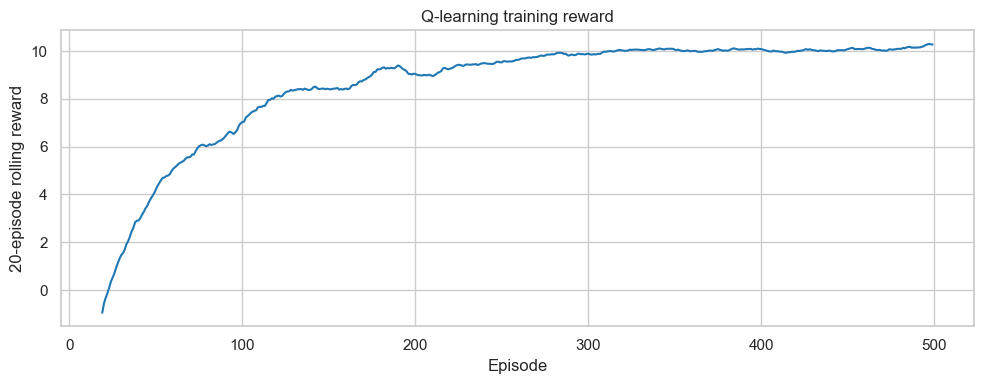

In [4]:
train_env = TradingEnvironment(train, state_columns=state_columns, transaction_cost=transaction_cost)
q_agent = QLearningAgent(alpha=0.08, gamma=0.95, epsilon=0.30, epsilon_decay=0.992, min_epsilon=0.03)
q_rewards = q_agent.train(train_env, episodes=500)

no_unsup_env = TradingEnvironment(train, state_columns=baseline_state_columns, transaction_cost=transaction_cost)
no_unsup_agent = QLearningAgent(alpha=0.08, gamma=0.95, epsilon=0.30, epsilon_decay=0.992, min_epsilon=0.03)
no_unsup_rewards = no_unsup_agent.train(no_unsup_env, episodes=500)

q_agent.save(MODEL_DIR / "q_learning.pkl")
no_unsup_agent.save(MODEL_DIR / "q_no_unsup.pkl")

pd.Series(q_rewards).rolling(20).mean().plot(figsize=(10, 4), color="tab:blue")
plt.title("Q-learning training reward")
plt.xlabel("Episode")
plt.ylabel("20-episode rolling reward")
plt.tight_layout()
plt.show()

The trained Q-learning models are saved before testing. This keeps training and evaluation separate.

## Load saved Q-learning models

From this point, test results use models loaded from `models/`, not the in-memory training objects.

In [5]:
loaded_q_agent = QLearningAgent.load(MODEL_DIR / "q_learning.pkl")
loaded_no_unsup_agent = QLearningAgent.load(MODEL_DIR / "q_no_unsup.pkl")

q_actions = loaded_q_agent.predict(TradingEnvironment(test, state_columns, transaction_cost))
no_unsup_actions = loaded_no_unsup_agent.predict(TradingEnvironment(test, baseline_state_columns, transaction_cost))
random_actions = random_policy_actions(len(test), random_state=7)

q_results = strategy_frame(test, q_actions, transaction_cost, "q_learning")
no_unsup_results = strategy_frame(test, no_unsup_actions, transaction_cost, "q_no_unsup")
random_results = strategy_frame(test, random_actions, transaction_cost, "random")
hold_results = buy_and_hold_frame(test)

comparison = (
    q_results[["date", "q_learning_return", "q_learning_equity", "action"]]
    .merge(no_unsup_results[["date", "q_no_unsup_return", "q_no_unsup_equity"]], on="date")
    .merge(random_results[["date", "random_return", "random_equity"]], on="date")
    .merge(hold_results[["date", "buy_hold_return", "buy_hold_equity"]], on="date")
)

## PPO idea

PPO is a policy-gradient RL method. This project uses a lightweight linear PPO-style policy so it runs without heavy deep-learning installs.

Here PPO receives scaled returns, volatility, RSI, MACD, ATR, regime, and PCA features directly.

In [6]:
ppo_train, ppo_test, ppo_scaler = scale_train_test(train, test, PPO_OBSERVATION_COLUMNS)
save_scaler(ppo_scaler, MODEL_DIR / "ppo_scaler.pkl")
loaded_ppo_scaler = load_scaler(MODEL_DIR / "ppo_scaler.pkl")

# For a full project run use [60, 300, 600].
# For a quick classroom/demo run, change this to smaller values like [10, 30, 60].
ppo_budgets_seconds = [60, 300, 600]

ppo_rows = []
ppo_actions = {}
for seconds in ppo_budgets_seconds:
    model, episodes, elapsed, rewards = train_ppo_for_seconds(
        ppo_train,
        PPO_OBSERVATION_COLUMNS,
        seconds=seconds,
        transaction_cost=transaction_cost,
    )
    model_path = MODEL_DIR / f"ppo_{seconds}s.pkl"
    model.save(model_path)

    loaded_model = LinearPPOAgent.load(model_path)
    actions = predict_ppo_actions(loaded_model, ppo_test, PPO_OBSERVATION_COLUMNS, transaction_cost)
    ppo_actions[seconds] = actions
    result = strategy_frame(test, actions, transaction_cost, "ppo")
    row_metrics = performance_metrics(result["ppo_return"], result["ppo_equity"], result["action"])
    ppo_rows.append({
        "seconds": seconds,
        "elapsed_seconds": elapsed,
        "episodes": episodes,
        "last_training_reward": rewards[-1] if rewards else np.nan,
        "model_path": str(model_path),
        **row_metrics,
    })

ppo_metrics = pd.DataFrame(ppo_rows)
ppo_metrics

,seconds,elapsed_seconds,episodes,last_training_reward,model_path,cumulative_return,average_daily_return,annualized_return,annualized_volatility,max_drawdown,hit_ratio,turnover
0,60,60.746141,29,-0.968921,C:\Users\Nitro\Desktop\Turing College\DS\3rd M...,-0.902390,-0.001224,-0.265532,0.507257,-0.959373,0.470852,0.178625
1,300,301.805487,139,0.752577,C:\Users\Nitro\Desktop\Turing College\DS\3rd M...,-0.771519,-0.000586,-0.137317,0.509300,-0.901926,0.481315,0.218984
2,600,601.137479,330,2.239847,C:\Users\Nitro\Desktop\Turing College\DS\3rd M...,-0.829596,-0.000808,-0.184367,0.507436,-0.941159,0.475336,0.171151


Each PPO-style model is saved and then loaded back before testing. The `model_path` column shows which saved file produced each row.

In [7]:
metric_rows = {
    "q_learning": performance_metrics(comparison["q_learning_return"], comparison["q_learning_equity"], q_results["action"]),
    "q_no_unsup": performance_metrics(comparison["q_no_unsup_return"], comparison["q_no_unsup_equity"], no_unsup_results["action"]),
    "buy_hold": performance_metrics(comparison["buy_hold_return"], comparison["buy_hold_equity"], pd.Series(np.ones(len(comparison)))),
    "random": performance_metrics(comparison["random_return"], comparison["random_equity"], pd.Series(random_actions)),
}

for seconds, actions in ppo_actions.items():
    result = strategy_frame(test, actions, transaction_cost, f"ppo_{seconds}s")
    metric_rows[f"ppo_{seconds}s"] = performance_metrics(
        result[f"ppo_{seconds}s_return"],
        result[f"ppo_{seconds}s_equity"],
        result["action"],
    )

metrics = pd.DataFrame(metric_rows).T
metrics[["cumulative_return", "annualized_return", "max_drawdown", "hit_ratio", "turnover"]]

,cumulative_return,annualized_return,max_drawdown,hit_ratio,turnover
q_learning,-0.962873,-0.392989,-0.972781,0.418535,0.497010
q_no_unsup,-0.803503,-0.187001,-0.887075,0.351271,0.588191
buy_hold,14.244645,0.902566,-0.663351,0.536622,0.000747
random,-0.544810,-0.057010,-0.677041,0.324365,0.864723
ppo_60s,-0.902390,-0.265532,-0.959373,0.470852,0.178625
ppo_300s,-0.771519,-0.137317,-0.901926,0.481315,0.218984
ppo_600s,-0.829596,-0.184367,-0.941159,0.475336,0.171151


Buy-and-hold strongly wins in this test period. The best PPO-style saved model still lost about 77%, while buy-and-hold gained more than 1,400%.

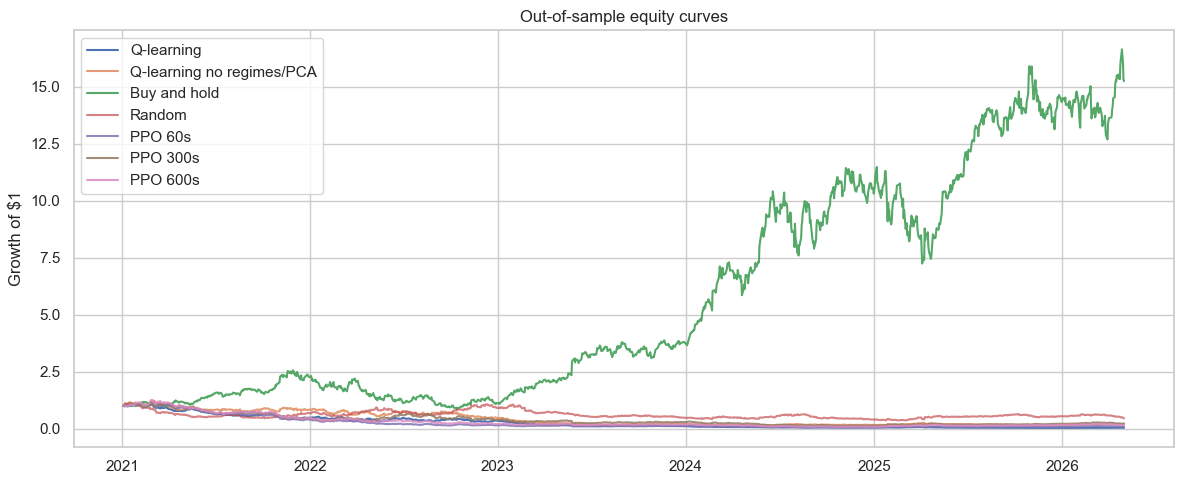

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(comparison["date"], comparison["q_learning_equity"], label="Q-learning")
plt.plot(comparison["date"], comparison["q_no_unsup_equity"], label="Q-learning no regimes/PCA", alpha=0.8)
plt.plot(comparison["date"], comparison["buy_hold_equity"], label="Buy and hold")
plt.plot(comparison["date"], comparison["random_equity"], label="Random", alpha=0.7)

for seconds, actions in ppo_actions.items():
    ppo_result = strategy_frame(test, actions, transaction_cost, f"ppo_{seconds}s")
    plt.plot(ppo_result["date"], ppo_result[f"ppo_{seconds}s_equity"], label=f"PPO {seconds}s", alpha=0.85)

plt.title("Out-of-sample equity curves")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

The equity curves show that the RL agents missed most of NVDA's bull-market upside. PPO traded less than random, but lower turnover did not make it profitable.

In [9]:
action_by_regime = (
    test.assign(action=q_actions)
    .groupby("regime")["action"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .pivot(index="regime", columns="action", values="share")
    .fillna(0)
)
action_by_regime

action,-1,0,1
regime,,,
0,0.877323,0.050186,0.072491
1,0.634033,0.235431,0.130536
2,0.676550,0.113208,0.210243


Q-learning shorted most often in every regime. It shorted least in the strong momentum regime, but the policy was still too bearish overall.

Final note:

This is a learning project. Real trading would need stronger validation, slippage modeling, and walk-forward testing.